# Nontrivial Decomposition

This chapter will discuss the cases where component peaks are not apparent.

## Initial Observation

Let us first observe such an example.

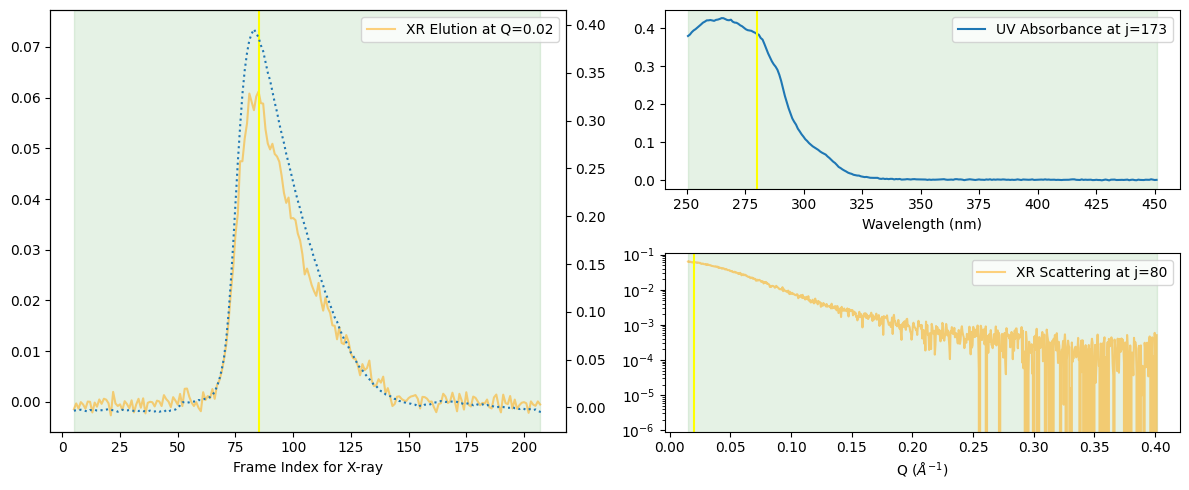

In [1]:
from molass import get_version
assert get_version() >= '0.6.0', "This tutorial requires molass version 0.6.0 or higher."
from molass_data import get_version
assert get_version() >= '0.3.0', "This tutorial requires molass_data version 0.3.0 or higher."
from molass_data import SAMPLE4
from molass.DataObjects import SecSaxsData as SSD
ssd = SSD(SAMPLE4)
trimmed_ssd = ssd.trimmed_copy()
corrected_ssd = trimmed_ssd.corrected_copy()
corrected_ssd.plot_compact();

At first glance, the peak may seem to consist of a single component. For a more detailed observation, let us assume it may consist of two components and add the Rg curve.  

  0%|          | 0/203 [00:00<?, ?it/s]

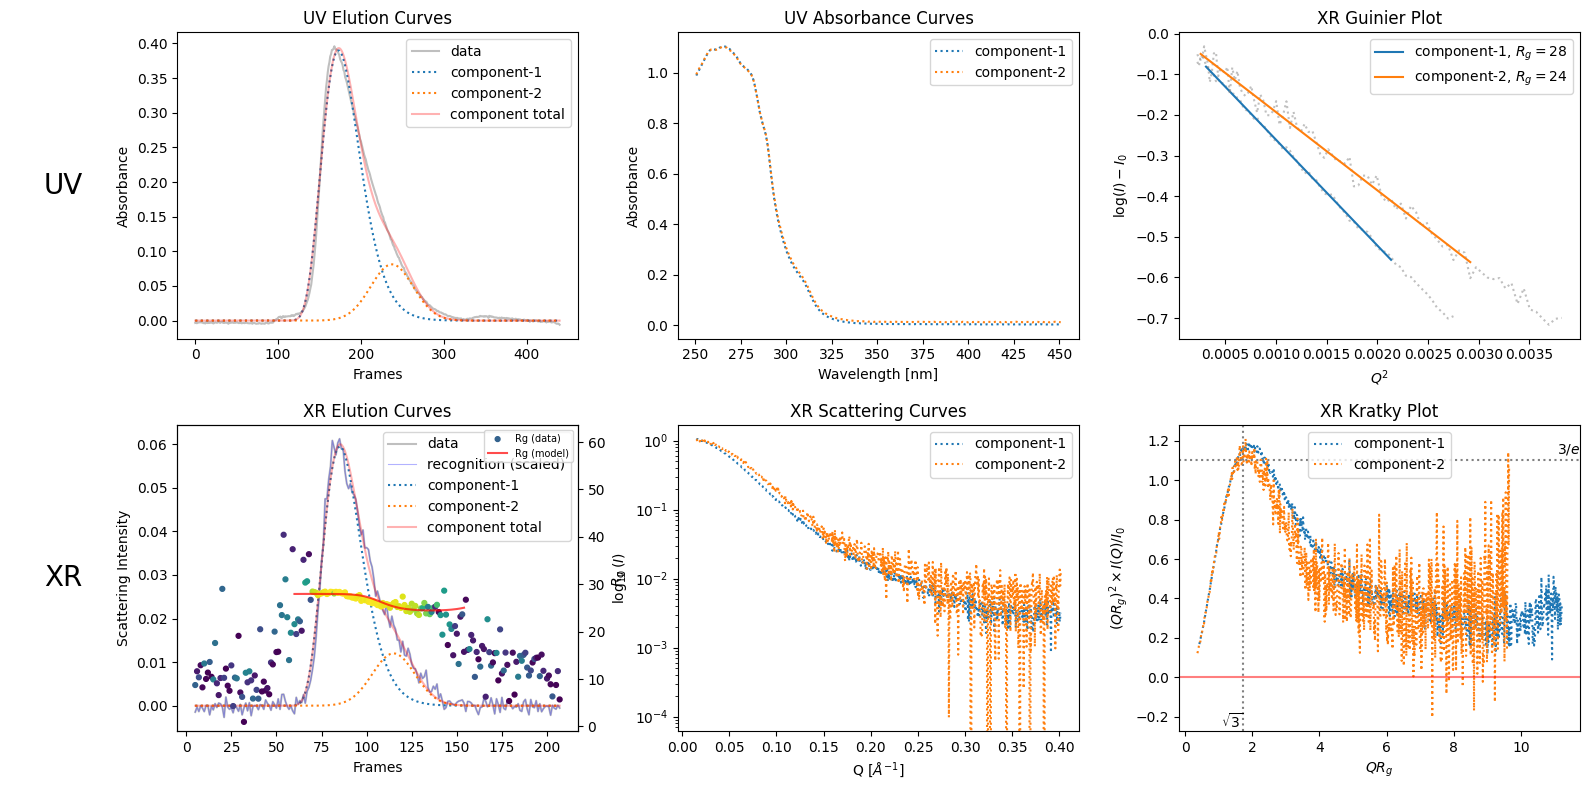

In [2]:
rgcurve = corrected_ssd.xr.compute_rgcurve()
decomposition = corrected_ssd.quick_decomposition(num_components=2)
decomposition.plot_components(rgcurve=rgcurve)

## Varied Binary Proportions

When component peaks overlap heavily, the default decomposition may produce
inconsistent results depending on noise, because its peak-recognition initialization
struggles to distinguish merged peaks.

The `proportions` option provides a more robust alternative.
It takes a list of approximate area ratios (one per component)
and uses a **proportional decomposition** algorithm that divides the elution curve
by cumulative area, providing better initialization for the optimizer.

The values do not need to be normalized or exact; for example,
`[1, 1]`, `[0.5, 0.5]`, and `[3, 3]` all give the same result.
Even a rough estimate like `[2, 1]` when the true ratio is `[1, 1]`
is usually sufficient.

To systematically explore which proportions work best,
you can use `plot_varied_decompositions()` as follows.

In [3]:
import numpy as np
num_trails = 8
species1_proportions = np.ones(num_trails) * 3
species2_proportions = np.linspace(1, 3, num_trails)
proportions = np.array([species1_proportions, species2_proportions]).T
proportions

array([[3.        , 1.        ],
       [3.        , 1.28571429],
       [3.        , 1.57142857],
       [3.        , 1.85714286],
       [3.        , 2.14285714],
       [3.        , 2.42857143],
       [3.        , 2.71428571],
       [3.        , 3.        ]])

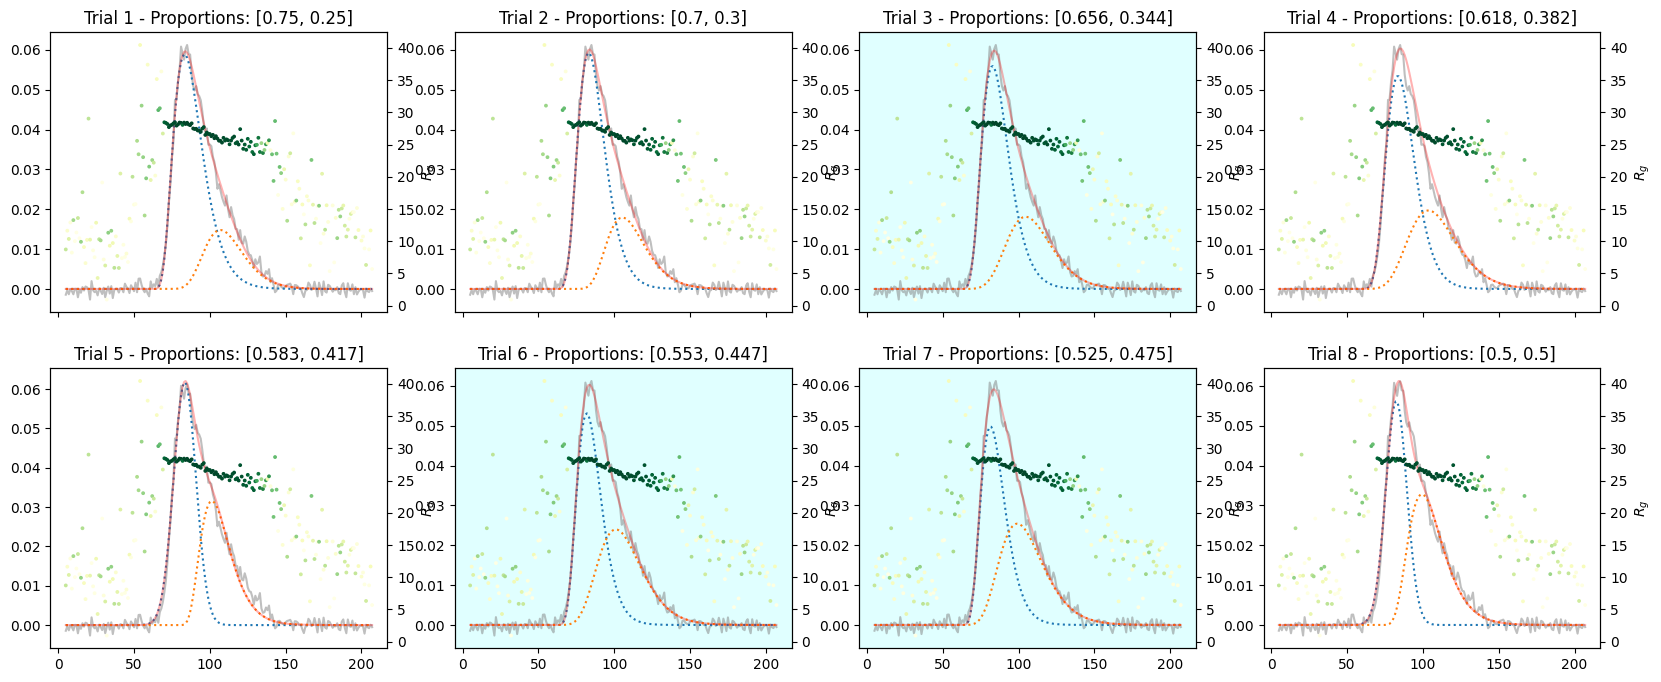

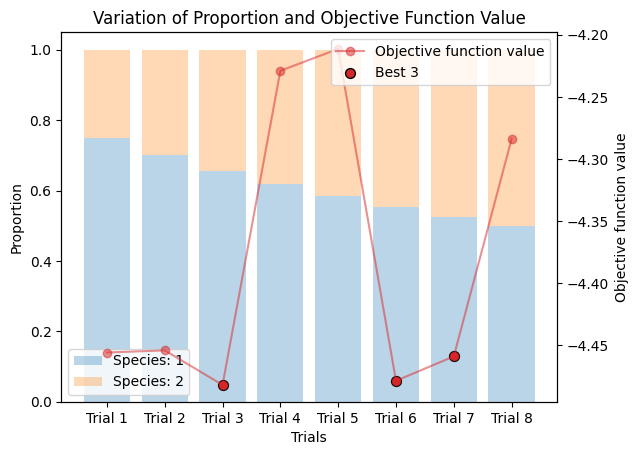

In [4]:
corrected_ssd.plot_varied_decompositions(proportions, rgcurve=rgcurve, best=3)

## Varied Tertiary Proportions

The same approach works for three or more components.
If the existence of three components is suspected, extend the proportions array with a third column.

In [5]:
species3_proportions = np.ones(num_trails) * 1
proportions = np.array([species1_proportions, species2_proportions, species3_proportions]).T
proportions


array([[3.        , 1.        , 1.        ],
       [3.        , 1.28571429, 1.        ],
       [3.        , 1.57142857, 1.        ],
       [3.        , 1.85714286, 1.        ],
       [3.        , 2.14285714, 1.        ],
       [3.        , 2.42857143, 1.        ],
       [3.        , 2.71428571, 1.        ],
       [3.        , 3.        , 1.        ]])

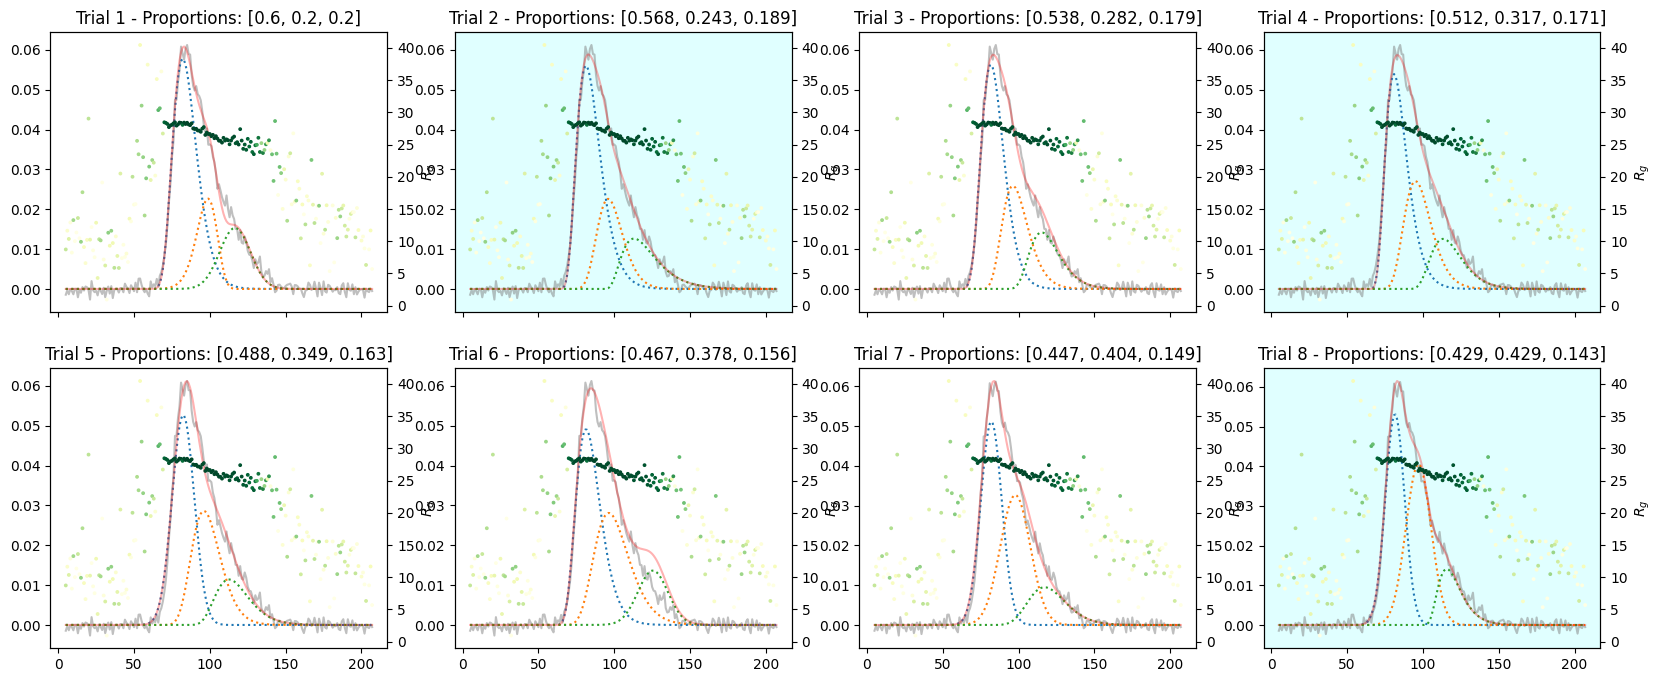

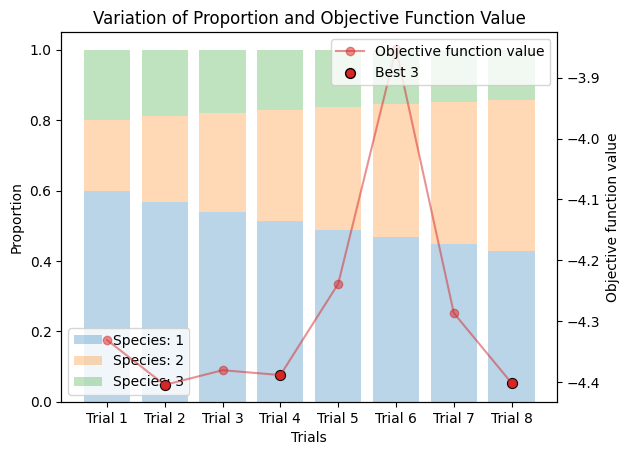

In [6]:
corrected_ssd.plot_varied_decompositions(proportions, rgcurve=rgcurve, best=3)